In [7]:
import numpy as np
import pandas as pd
import rustima

In [8]:
df = pd.read_csv('/Users/icy71/Documents/GitHub/Rust-python-arima/total_heat_demand_dwh.csv')

In [9]:
# 파주 지점만 필터링
df_paju = df[df['branch_id'] == '파주'].copy()

# 날짜 파싱 + 시간 인덱스 설정
df_paju['date'] = pd.to_datetime(df_paju['date'])
df_paju = df_paju.sort_values('date').reset_index(drop=True)
df_paju = df_paju.set_index('date')

# 시간당 빈도로 재인덱싱해서 누락된 시점 확인 (hourly)
full_idx = pd.date_range(df_paju.index.min(), df_paju.index.max(), freq='h')
missing_hours = full_idx.difference(df_paju.index)

In [10]:
y_paju = df_paju['heat_demand'].asfreq('h') 

## 예측

In [11]:
# ── 추가 import + Train/Test 분할 + order 정의 ─────────────
import time, warnings
import matplotlib.pyplot as plt
import matplotlib as mpl

from rustima import SARIMAXModel, auto_arima as rs_auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm

mpl.rcParams['font.family'] = 'AppleGothic'
mpl.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')

# y_paju가 interpolate 안 됐을 가능성 방어
if y_paju.isna().any():
    y_paju = y_paju.interpolate(method='linear')

# Train(2021~2023.11) / Test(2023.12) / Search(2023.09~11)
y_train  = y_paju.loc[:'2023-11-30 23:00:00']
y_test   = y_paju.loc['2023-12-01 00:00:00':]
y_search = y_paju.loc['2023-09-01':'2023-11-30 23:00:00']

# auto_arima 탐색으로 확정된 베스트 order
ORDER     = (3, 0, 5)
SEASONAL  = (2, 1, 2, 24)
TREND     = 'n'

y_tr = y_train.to_numpy().astype(np.float64)
print(f"y_train  : {len(y_train):>7,}h  ({y_train.index.min()} ~ {y_train.index.max()})")
print(f"y_test   : {len(y_test):>7,}h")
print(f"y_search : {len(y_search):>7,}h")
print(f"ORDER={ORDER}, SEASONAL={SEASONAL}, trend='{TREND}'")

y_train  :  25,535h  (2021-01-01 01:00:00 ~ 2023-11-30 23:00:00)
y_test   :     744h
y_search :   2,184h
ORDER=(3, 0, 5), SEASONAL=(2, 1, 2, 24), trend='n'


### Part 1. SARIMAX fit — rustima vs statsmodels
동일 order, 동일 데이터(y_train, n≈26,000). 상태 차원 k≈78 → statsmodels는 수 분 걸릴 수 있음.

In [12]:
# ── rustima fit ────────────────────────────────────────────
t0 = time.perf_counter()
rs_model = SARIMAXModel(
    y_tr,
    order=ORDER, seasonal_order=SEASONAL, trend=TREND,
    enforce_stationarity=True, enforce_invertibility=True,
)
rs_res = rs_model.fit(method='lbfgsb', maxiter=500)
rs_elapsed = time.perf_counter() - t0

print(f"[rustima] {rs_elapsed:.2f}s  converged={rs_res.converged}")
print(f"  loglike={rs_res.llf:.3f}  AIC={rs_res.aic:.3f}  BIC={rs_res.bic:.3f}")
print(f"  sigma²={rs_res.scale:.4f}")

[rustima] 48.67s  converged=True
  loglike=-78876.116  AIC=157778.231  BIC=157884.153
  sigma²=28.3375


In [13]:
# ── statsmodels fit ────────────────────────────────────────
# ⚠ 수 분 ~ 수십 분 걸릴 수 있음
t0 = time.perf_counter()
sm_model = SARIMAX(
    y_tr,
    order=ORDER, seasonal_order=SEASONAL, trend=TREND,
    enforce_stationarity=True, enforce_invertibility=True,
    concentrate_scale=True,
)
sm_res = sm_model.fit(disp=False, maxiter=500, method='lbfgs')
sm_elapsed = time.perf_counter() - t0

print(f"[statsmodels] {sm_elapsed:.2f}s  converged={sm_res.mle_retvals.get('converged', '?')}")
print(f"  loglike={sm_res.llf:.3f}  AIC={sm_res.aic:.3f}  BIC={sm_res.bic:.3f}")

[statsmodels] 342.29s  converged=True
  loglike=-79119.461  AIC=158264.921  BIC=158370.830


In [14]:
# ── fit 결과 비교 표 ────────────────────────────────────────
rows = [
    ('Fit time (s)',   rs_elapsed,    sm_elapsed,   f"{sm_elapsed/rs_elapsed:.1f}x 빠름"),
    ('Log-likelihood', rs_res.llf,    sm_res.llf,   f"|Δ|={abs(rs_res.llf - sm_res.llf):.4f}"),
    ('AIC',            rs_res.aic,    sm_res.aic,   f"|Δ|={abs(rs_res.aic - sm_res.aic):.4f}"),
    ('BIC',            rs_res.bic,    sm_res.bic,   f"|Δ|={abs(rs_res.bic - sm_res.bic):.4f}"),
    ('Sigma²',         rs_res.scale,  sm_res.scale, f"|Δ|={abs(rs_res.scale - sm_res.scale):.4f}"),
]
df_cmp = pd.DataFrame(rows, columns=['Metric', 'rustima', 'statsmodels', '비교'])
print(df_cmp.to_string(index=False))

# 파라미터 비교
print('\n[Parameters]')
n_common = min(len(rs_res.params), len(sm_res.params))
param_cmp = pd.DataFrame({
    'name':        rs_res.param_names[:n_common],
    'rustima':     rs_res.params[:n_common],
    'statsmodels': sm_res.params[:n_common],
})
param_cmp['|Δ|'] = (param_cmp['rustima'] - param_cmp['statsmodels']).abs()
print(param_cmp.to_string(index=False))

        Metric       rustima   statsmodels           비교
  Fit time (s)     48.666671    342.293395      7.0x 빠름
Log-likelihood -78876.115584 -79119.460559 |Δ|=243.3450
           AIC 157778.231168 158264.921117 |Δ|=486.6899
           BIC 157884.152637 158370.830362 |Δ|=486.6777
        Sigma²     28.337533     28.885279   |Δ|=0.5477

[Parameters]
    name   rustima  statsmodels      |Δ|
   ar.L1  0.793345     1.510570 0.717225
   ar.L2  0.899511    -1.233322 2.132834
   ar.L3 -0.695498     0.664637 1.360135
   ma.L1  0.270395    -0.436473 0.706868
   ma.L2 -0.846328     0.537586 1.383914
   ma.L3 -0.312999    -0.038317 0.274682
   ma.L4 -0.061860    -0.042134 0.019726
   ma.L5  0.057548    -0.134616 0.192164
ar.S.L24  0.787359     0.789203 0.001844
ar.S.L48 -0.226667    -0.232540 0.005873
ma.S.L24 -1.538846    -1.526169 0.012678
ma.S.L48  0.588561     0.583952 0.004609


### Part 2. Forecast — 2023-12 테스트 구간
`y_train` 끝점에서 `len(y_test)`h 예측 → 실제와 비교 (RMSE, MAE)

In [15]:
h = len(y_test)

# rustima forecast
t0 = time.perf_counter()
rs_fcast = rs_res.forecast(steps=h, alpha=0.05)
rs_fc_time = time.perf_counter() - t0

# statsmodels forecast
t0 = time.perf_counter()
sm_fcast = sm_res.get_forecast(steps=h)
sm_mean = sm_fcast.predicted_mean
sm_ci = sm_fcast.conf_int(alpha=0.05)
sm_fc_time = time.perf_counter() - t0

# 정확도 지표
y_true = y_test.to_numpy()
def _metrics(yhat):
    err = y_true - np.asarray(yhat)
    return np.sqrt(np.mean(err**2)), np.mean(np.abs(err))

rs_rmse, rs_mae = _metrics(rs_fcast.predicted_mean)
sm_rmse, sm_mae = _metrics(sm_mean)

print(f"Forecast time — rustima: {rs_fc_time*1000:.1f}ms   statsmodels: {sm_fc_time*1000:.1f}ms")
print()
print(f"{'engine':12s} | {'RMSE':>10s} | {'MAE':>10s}")
print('-' * 40)
print(f"{'rustima':12s} | {rs_rmse:10.3f} | {rs_mae:10.3f}")
print(f"{'statsmodels':12s} | {sm_rmse:10.3f} | {sm_mae:10.3f}")

Forecast time — rustima: 243.5ms   statsmodels: 79.0ms

engine       |       RMSE |        MAE
----------------------------------------
rustima      |     31.767 |     26.261
statsmodels  |     37.080 |     29.805


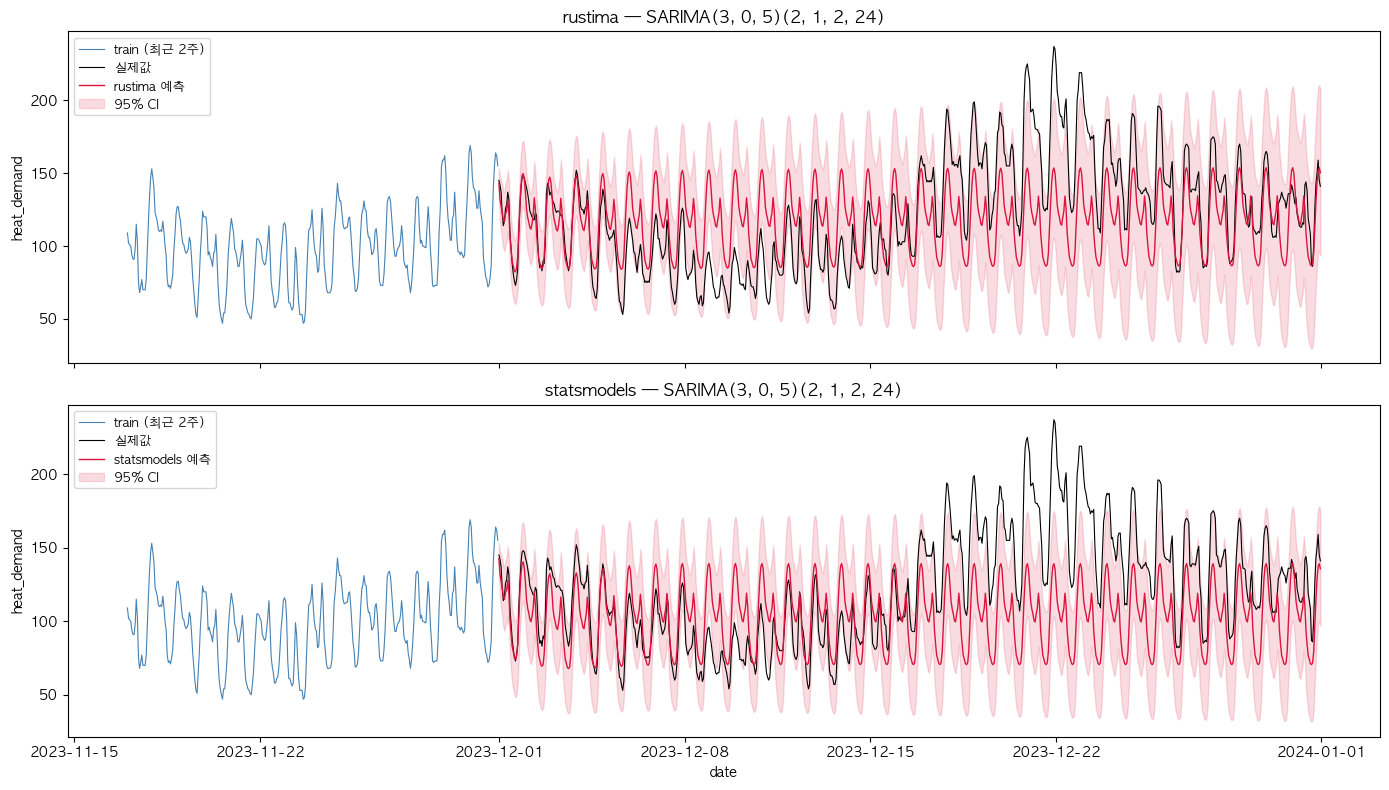

In [16]:
# ── 예측 vs 실제 플롯 ───────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# 최근 2주 train + 전체 test
ctx = y_train.iloc[-24*14:]

sm_ci_lo = sm_ci.iloc[:, 0].to_numpy() if hasattr(sm_ci, 'iloc') else sm_ci[:, 0]
sm_ci_hi = sm_ci.iloc[:, 1].to_numpy() if hasattr(sm_ci, 'iloc') else sm_ci[:, 1]

for ax, (name, mean, ci_lo, ci_hi) in zip(axes, [
    ('rustima',     rs_fcast.predicted_mean, rs_fcast.ci_lower, rs_fcast.ci_upper),
    ('statsmodels', np.asarray(sm_mean),     sm_ci_lo,           sm_ci_hi),
]):
    ax.plot(ctx.index, ctx.values, color='steelblue', lw=0.8, label='train (최근 2주)')
    ax.plot(y_test.index, y_test.values, color='black', lw=0.8, label='실제값')
    ax.plot(y_test.index, mean, color='crimson', lw=1.0, label=f'{name} 예측')
    ax.fill_between(y_test.index, ci_lo, ci_hi, color='crimson', alpha=0.15, label='95% CI')
    ax.set_title(f'{name} — SARIMA{ORDER}{SEASONAL}')
    ax.set_ylabel('heat_demand')
    ax.legend(loc='upper left', fontsize=9)

axes[-1].set_xlabel('date')
plt.tight_layout()
plt.show()

## auto_arima 속도 비교 — rustima vs pmdarima

같은 데이터(`y_paju`의 subset) · 같은 탐색 방식(stepwise) · 같은 기준(AIC)으로 두 엔진 탐색 시간 비교.

> pmdarima는 **stepwise + Python 순차 실행**이라 `s=24` 시계열에서 매우 느림. 전체 3년(n=26,279)은 수 시간 단위라 여기서는 **최근 60일(1,440h)** subset으로 비교.

In [ ]:
# ── auto_arima 속도 비교 ────────────────────────────────────
import time, warnings
import numpy as np
from rustima import auto_arima as rs_auto
import pmdarima as pm

warnings.filterwarnings('ignore')

# 최근 60일(1,440h) subset
y_sub = y_paju.iloc[-60*24:].to_numpy().astype(np.float64)
print(f"비교 데이터: {len(y_sub)}h (최근 60일)")
print()

# --- rustima auto_arima (stepwise) ---
t0 = time.perf_counter()
auto_rs = rs_auto(y_sub, s=24, trend='n', stepwise=True, trace=False)
t_rs = time.perf_counter() - t0
print(f"rustima  : {auto_rs.order}{auto_rs.seasonal_order}, "
      f"AIC={auto_rs.result.aic:.2f}, time={t_rs:.3f}s")

# --- pmdarima auto_arima (stepwise) ---
t0 = time.perf_counter()
auto_pm = pm.auto_arima(
    y_sub,
    seasonal=True, m=24, trend=None,
    stepwise=True, suppress_warnings=True,
)
t_pm = time.perf_counter() - t0
print(f"pmdarima : {auto_pm.order}{auto_pm.seasonal_order}, "
      f"AIC={auto_pm.aic():.2f}, time={t_pm:.3f}s")

print(f"\n속도 비교: rustima {t_pm/t_rs:.1f}x faster")